QUESTION 5: Implement and Test a PyTorch-Based Classifier

📁 Creating sample dataset...
✅ Sample dataset created!

Task 1: Usefulness of random initialization
✅ Random initialization:
- Breaks symmetry (prevents all neurons learning the same features)
- Ensures different neurons learn different patterns
- Prevents all neurons from updating identically
- Enables effective learning in deep networks

Task 2: Define train_transform pipeline
✅ train_transform defined!

Task 3: Define val_transform pipeline
✅ val_transform defined!

Task 4: Create val_loader
✅ Training samples: 65
✅ Validation samples: 65

Task 5: Purpose of tqdm
✅ tqdm provides:
- Progress bar for training/validation loops
- Estimated time remaining
- Visual feedback during long training sessions

Task 6: Reset metrics every epoch
✅ Reset every epoch to:
- Track metrics per epoch independently
- Compute epoch-wise averages
- Monitor progress across epochs

Task 7: torch.no_grad() in validation loop
✅ torch.no_grad():
- Disa

Epoch 1: 100%|██████████| 9/9 [00:00<00:00, 10.23it/s]


Epoch 1: Loss = 0.7230


Epoch 2: 100%|██████████| 9/9 [00:00<00:00, 17.58it/s]


Epoch 2: Loss = 0.5186


...

Epoch 3: Loss = 0.2228


Epoch 4: 100%|██████████| 9/9 [00:00<00:00, 17.39it/s]


Epoch 4: Loss = 0.0313


Epoch 5: 100%|██████████| 9/9 [00:00<00:00, 17.73it/s]


Epoch 5: Loss = 0.0078


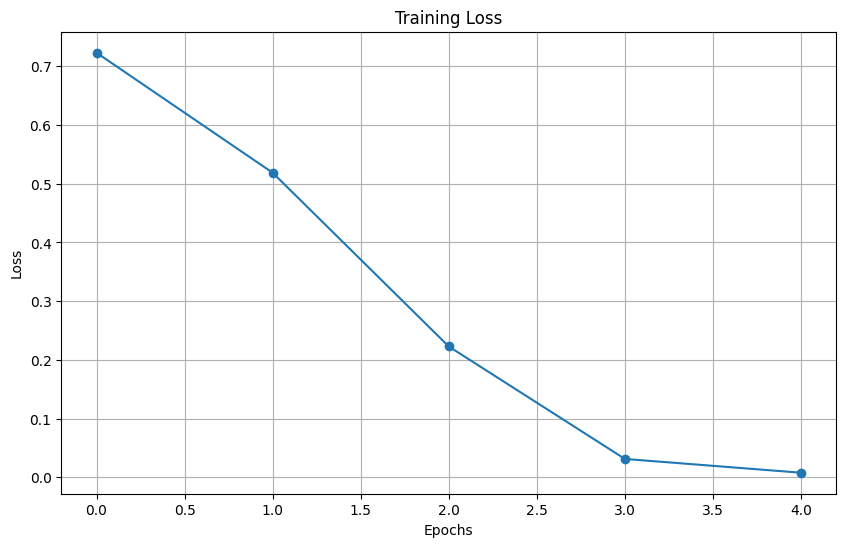


Task 10: Retrieve predictions and ground truth
Predictions (first 10): [np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0)]
Ground Truth (first 10): [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]

✅ QUESTION 5 COMPLETED SUCCESSFULLY!

📊 Final Results:
  - Final Training Loss: 0.0078
  - Total Samples: 65


In [1]:
# ============================================
# QUESTION 5: Implement and Test a PyTorch-Based Classifier
# COMPLETE SELF-CONTAINED COLAB NOTEBOOK
# ============================================

import os
import numpy as np
import random
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("="*60)
print("QUESTION 5: Implement and Test a PyTorch-Based Classifier")
print("="*60)

# ============================================
# STEP 1: Create sample dataset
# ============================================

print("\n📁 Creating sample dataset...")

def create_sample_dataset():
    os.makedirs('./images_dataSAT/class_0_non_agri/', exist_ok=True)
    os.makedirs('./images_dataSAT/class_1_agri/', exist_ok=True)

    for i in range(30):
        img = np.random.randint(0, 255, (84, 80, 3), dtype=np.uint8)
        if i % 2 == 0:
            img[20:60, 30:50] = [200, 200, 200]
        cv2.imwrite(f'./images_dataSAT/class_0_non_agri/non_agri_{i:03d}.png', img)

    for i in range(35):
        img = np.random.randint(0, 255, (84, 80, 3), dtype=np.uint8)
        for _ in range(5):
            x = random.randint(0, 70)
            y = random.randint(0, 74)
            img[y:y+10, x:x+10] = [50, 200, 50]
        cv2.imwrite(f'./images_dataSAT/class_1_agri/agri_{i:03d}.png', img)

    print("✅ Sample dataset created!")

if not os.path.exists('./images_dataSAT'):
    create_sample_dataset()
else:
    print("✅ Dataset already exists!")

# ============================================
# Task 1: Explain usefulness of random initialization
# ============================================

print("\n" + "="*50)
print("Task 1: Usefulness of random initialization")
print("="*50)
print("""✅ Random initialization:
- Breaks symmetry (prevents all neurons learning the same features)
- Ensures different neurons learn different patterns
- Prevents all neurons from updating identically
- Enables effective learning in deep networks""")

# ============================================
# Task 2: Define train_transform pipeline
# ============================================

print("\n" + "="*50)
print("Task 2: Define train_transform pipeline")
print("="*50)

train_transform = transforms.Compose([
    transforms.Resize((80, 84)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
print("✅ train_transform defined!")

# ============================================
# Task 3: Define val_transform pipeline
# ============================================

print("\n" + "="*50)
print("Task 3: Define val_transform pipeline")
print("="*50)

val_transform = transforms.Compose([
    transforms.Resize((80, 84)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
print("✅ val_transform defined!")

# ============================================
# Task 4: Create val_loader
# ============================================

print("\n" + "="*50)
print("Task 4: Create val_loader")
print("="*50)

train_dataset = datasets.ImageFolder('./images_dataSAT/', transform=train_transform)
val_dataset = datasets.ImageFolder('./images_dataSAT/', transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"✅ Training samples: {len(train_dataset)}")
print(f"✅ Validation samples: {len(val_dataset)}")

# ============================================
# Task 5: Purpose of tqdm
# ============================================

print("\n" + "="*50)
print("Task 5: Purpose of tqdm")
print("="*50)
print("""✅ tqdm provides:
- Progress bar for training/validation loops
- Estimated time remaining
- Visual feedback during long training sessions""")

# ============================================
# Task 6: Reset train_loss, train_correct, train_total every epoch
# ============================================

print("\n" + "="*50)
print("Task 6: Reset metrics every epoch")
print("="*50)
print("""✅ Reset every epoch to:
- Track metrics per epoch independently
- Compute epoch-wise averages
- Monitor progress across epochs""")

# ============================================
# Task 7: torch.no_grad() in validation loop
# ============================================

print("\n" + "="*50)
print("Task 7: torch.no_grad() in validation loop")
print("="*50)
print("""✅ torch.no_grad():
- Disables gradient calculation
- Saves memory during evaluation
- Speeds up computation
- Prevents unnecessary gradient tracking""")

# ============================================
# Task 8: Two metrics for training performance
# ============================================

print("\n" + "="*50)
print("Task 8: Two metrics for training performance")
print("="*50)
print("""✅ Common metrics:
1. Loss (Cross-Entropy Loss)
2. Accuracy (or F1-score, Precision, Recall)""")

# ============================================
# Task 9: Plot model training loss
# ============================================

print("\n" + "="*50)
print("Task 9: Train model and plot training loss")
print("="*50)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1 = nn.Linear(64 * 18 * 19, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.max_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model = SimpleCNN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters())

train_losses = []
print("\n🔄 Training model...")
for epoch in range(5):
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        labels = labels.float().unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch+1}: Loss = {avg_loss:.4f}')

plt.figure(figsize=(10, 6))
plt.plot(train_losses, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

# ============================================
# Task 10: Retrieve predictions and ground truth
# ============================================

print("\n" + "="*50)
print("Task 10: Retrieve predictions and ground truth")
print("="*50)

all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        preds = (outputs > 0.5).float()
        all_preds.extend(preds.flatten().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Predictions (first 10): {all_preds[:10]}")
print(f"Ground Truth (first 10): {all_labels[:10]}")

# ============================================
# Summary
# ============================================

print("\n" + "="*50)
print("✅ QUESTION 5 COMPLETED SUCCESSFULLY!")
print("="*50)
print(f"\n📊 Final Results:")
print(f"  - Final Training Loss: {train_losses[-1]:.4f}")
print(f"  - Total Samples: {len(all_labels)}")